# Laboratory work 3

## Modeling a Bayesian classifier for Gaussian random vectors

Importing libs


In [331]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Making class to work with Bayesian classifier

In [332]:
from collections.abc import Callable

class BayesianClassifier:
    def __init__(self, N: int, L:int):
        self.N = N
        self.L = L
        self.a_priori_probabilities = []
        self.conditional_densities = []

    def _gaussian_density_one_point(self, mu: np.ndarray, sigma: np.ndarray)->Callable:
        density = lambda x: (2 * np.pi) ** (-self.N/2) * np.linalg.det(sigma) ** (-1/2) \
            * np.exp(-(x - mu).T @ np.linalg.inv(sigma) @ (x - mu) / 2)
        return density

    def gaussian_density(self, mu: np.ndarray, sigma:np.ndarray)->list[Callable]:
        densities = []
        for i in range(self.L):
            densities.append(self._gaussian_density_one_point(mu[i], sigma[i]))
        
        return densities
    
    def set_probability_characteristics(self, apriory_probabilities: list[float],
                                         conditional_densities: list[Callable])->None:
        self.a_priori_probabilities = apriory_probabilities
        self.conditional_densities = conditional_densities

    def probabilities(self, x: np.ndarray)->list[float]:
        a_posteriori_probabilities: list[float] = []
        f: list[float] = []
        for i in range(self.L):
            f.append(self.a_priori_probabilities[i] * self.conditional_densities[i](x))

        summ = sum(f)
        for i in range(self.L):
            a_posteriori_probabilities.append(f[i] / summ)

        return a_posteriori_probabilities
    
    def fit(self, X: np.ndarray, y: np.ndarray)->None:
        self.a_priori_probabilities = []
        self.densities = []
        for i in range(self.L):
            mask = (y == (i+1))
            count = len(y[mask])
            self.a_priori_probabilities.append(count / len(y))

            mean = np.mean(X[mask], axis=0)
            cov = np.cov(X[mask], rowvar=False)
            density = self._gaussian_density_one_point(mean, cov)
            self.densities.append(density)
        return None
    
    def _predict_one_point(self, x: np.ndarray)->int:
        return int(np.argmax(self.probabilities(x))) + 1
    
    def predict(self, x: np.ndarray)->np.ndarray:
        y = np.array([self._predict_one_point(i) for i in x])
        return y

Declarating function to draw ellipsoid of conditional gaussian densities

In [333]:
from scipy.stats import chi2
from matplotlib.patches import Ellipse

def plot_ellipsoid(ax, mu: np.ndarray, sigma: np.ndarray, color: str, alpha=0.95):
    chi2_val = chi2.ppf(alpha, df=2)
    eigvals, eigvecs = np.linalg.eigh(sigma)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width = 2 * np.sqrt(eigvals[0] * chi2_val)
    height = 2 * np.sqrt(eigvals[1] * chi2_val)
    
    ell = Ellipse(xy=mu.tolist(), width=width, height=height, angle=angle, color=color)
    ax.add_patch(ell)

In [334]:
def generate_sample(n_classes: int, mus: np.ndarray, sigmas: np.ndarray, n_samples: int)->pd.DataFrame:
    dfs = []
    for i in range(n_classes):
        random_variables = np.random.multivariate_normal(mus[i], sigmas[i], n_samples // n_classes)
        columns_names = [f"x_{j+1}" for j in range(random_variables.shape[1])]
        buff_df = pd.DataFrame(random_variables, columns=columns_names)
        buff_df['label'] = i + 1
        dfs.append(buff_df)
    df: pd.DataFrame = pd.concat(dfs, ignore_index=True)
    df = df.sample(frac=1).reset_index(drop=True)
    return df

In [335]:
def accuracy_rate(y_true: np.ndarray, y_pred: np.ndarray)->float:
    return (y_true == y_pred).sum() / len(y_true)

### 1. All probability characteristics are known.

$N=2, L=2, \pi_1 = \pi_2 = 0.5, M_i=M_i'=20, i=1,2, K=20$

$\mu_1 = (-1, -1)^T,\ \mu_2=(1, 1)^T$

In [336]:
bc = BayesianClassifier(2, 2)
a_priori = [0.5, 0.5]
mu_1 = np.array([-1, -1])
mu_2 = np.array([1, 1])
mus = np.stack((mu_1, mu_2))

A) $\Sigma_1=\Sigma_2=\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$

In [337]:
sigma = np.array([[1, 0], [0, 1]])
sigmas_a = np.stack((sigma, sigma))

In [338]:
df_test = generate_sample(2, mus, sigmas_a, 20)
df_test.head()

,x_1,x_2,label
0,0.795758,1.752769,2
1,0.517759,-0.278134,1
2,0.318357,1.495880,2
3,0.891027,0.502098,2
4,1.264283,1.107692,2


In [339]:
densities = bc.gaussian_density(mus, sigmas_a)

bc.set_probability_characteristics(a_priori, densities)
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.9)

In [340]:
n_samples = 20

df_train = generate_sample(2, mus, sigmas_a, n_samples)
df_train.head()

,x_1,x_2,label
0,-2.333252,0.162120,1
1,-1.262485,-0.342100,1
2,1.410218,3.514666,2
3,-2.489278,-1.829090,1
4,1.365886,-0.212642,2


In [341]:
bc.fit(df_train.iloc[:, :-1].to_numpy(), df_train['label'].to_numpy())
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].values, y_pred)

np.float64(0.9)

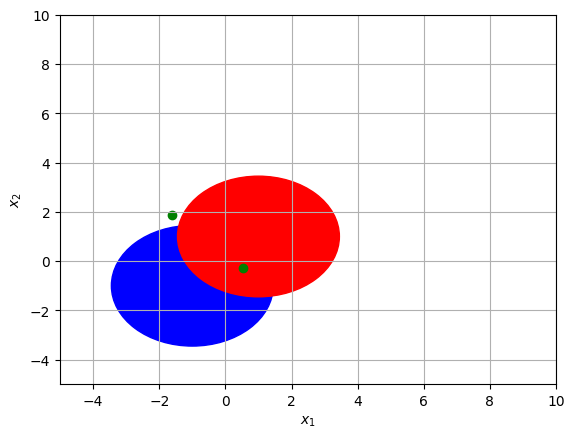

In [342]:
df_wrong = df_test[y_pred != df_test['label']][['x_1', 'x_2']]

fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma, 'blue')
plot_ellipsoid(ax, mu_2, sigma, 'red')
plt.scatter(x = df_wrong['x_1'], y=df_wrong['x_2'], color='green')
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

B) $\Sigma_1 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$, $\Sigma_2 = \begin{pmatrix} 2 & 0 \\ 0 & 2 \end{pmatrix}$

In [343]:
sigma_b1 = np.array([[1, 0], [0, 1]])
sigma_b2 = np.array([[2, 0], [0, 2]])
sigmas_b = np.stack((sigma_b1, sigma_b2))
densities = bc.gaussian_density(mus, sigmas_b)

In [344]:
df_test = generate_sample(2, mus, sigmas_b, n_samples)
df_test.head()

,x_1,x_2,label
0,-2.252196,-0.474408,1
1,0.801063,1.799384,2
2,0.139607,-4.005226,1
3,-0.157383,1.576487,2
4,-0.582064,-2.871124,1


In [345]:
bc.set_probability_characteristics(a_priori, densities)
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.9)

In [346]:
n_samples = 20
df_train = generate_sample(2, mus, sigmas_b, n_samples)
df_train.head()

,x_1,x_2,label
0,1.014354,0.035676,2
1,0.146003,2.760224,2
2,-1.289174,-1.812597,1
3,0.166884,1.885824,2
4,-0.900865,-1.000966,1


In [347]:
bc.fit(df_train.iloc[:, :-1].to_numpy(), df_train['label'].to_numpy())
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].values, y_pred)

np.float64(0.9)

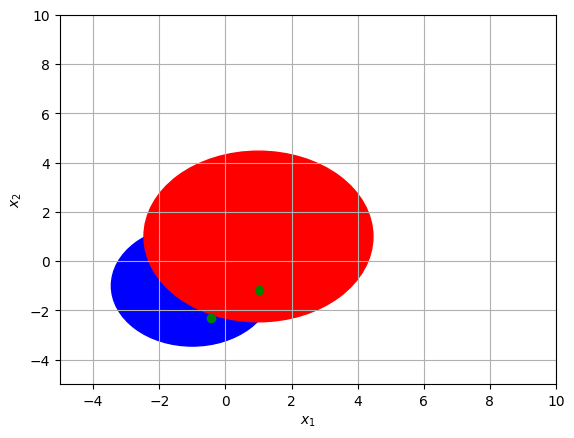

In [348]:
df_wrong = df_test[y_pred != df_test['label']][['x_1', 'x_2']]

fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma_b1, 'blue')
plot_ellipsoid(ax, mu_2, sigma_b2, 'red')
plt.scatter(x = df_wrong['x_1'], y=df_wrong['x_2'], color='green')
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

C) $\Sigma_1 = \begin{pmatrix} 1 & 0.5 \\ 0.5 & 1 \end{pmatrix}$, $\Sigma_2 = \begin{pmatrix} 2 & -1.5 \\ -1.5 & 2 \end{pmatrix}$

In [349]:
sigma_c1 = np.array([[1, 0.5], [0.5, 1]])
sigma_c2 = np.array([[2, -1.5], [-1.5, 2]])
sigmas_c = np.stack((sigma_c1, sigma_c2))
densities = bc.gaussian_density(mus, sigmas_c)

In [350]:
df_test = generate_sample(2, mus, sigmas_a, n_samples)
df_test.head()

,x_1,x_2,label
0,1.334602,-1.429577,2
1,-1.424401,-0.763396,1
2,-1.878399,-0.202928,1
3,-1.210530,0.187009,1
4,-0.690171,1.010013,2


In [351]:
bc.set_probability_characteristics(a_priori, densities)
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.95)

In [352]:
n_samples = 20
df_train = generate_sample(2, mus, sigmas_c, n_samples)
df_train.head()

,x_1,x_2,label
0,1.083706,0.521533,2
1,-0.759959,-0.739142,1
2,0.386025,-0.095358,1
3,0.437705,0.015823,1
4,-1.954280,-1.820069,1


In [353]:
bc.fit(df_train.iloc[:, :-1].to_numpy(), df_train['label'].to_numpy())
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.95)

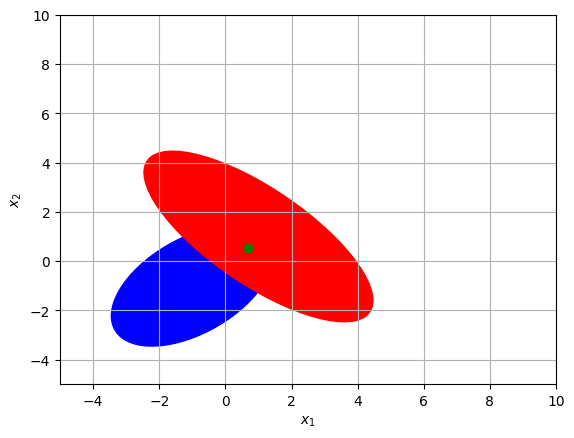

In [354]:
df_wrong = df_test[y_pred != df_test['label']][['x_1', 'x_2']]

fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma_c1, 'blue')
plot_ellipsoid(ax, mu_2, sigma_c2, 'red')
plt.scatter(x = df_wrong['x_1'], y=df_wrong['x_2'], color='green')
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

$N=2, L=4, \pi_1 = \pi_i = 0.25, M_i=M_i'=20, i=\overline{1,4}, K=20$

$\mu_1 = (-1, -1)^T,\ \mu_2=(-1, 1)^T,\ \mu_3=(1, 1)^T,\ \mu_4=(1,-1)^T$

$\Sigma_1 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix},\ \Sigma_2 = \begin{pmatrix} 1 & 0.5 \\ 0.5 & 1 \end{pmatrix},\ \Sigma_3 = \begin{pmatrix} 2 & 0 \\ 0 & 2 \end{pmatrix},\ \Sigma_4 = \begin{pmatrix} 1 & -0.5 \\ -0.5 & 1 \end{pmatrix}$

In [355]:
bc2 = BayesianClassifier(N=2, L=4)
a_priori = [0.25, 0.25, 0.25, 0.25]

mu_1 = np.array([-1, -1])
mu_2 = np.array([-1, 1])
mu_3 = np.array([1, 1])
mu_4 = np.array([1, -1])
mus_2 = np.stack((mu_1, mu_2, mu_3, mu_4))

sigma_1 = np.array([[1, 0], [0, 1]])
sigma_2 = np.array([[1, 0.5], [0.5, 1]])
sigma_3 = np.array([[2, 0], [0, 2]])
sigma_4 = np.array([[1, -0.5], [-0.5, 1]])
sigmas_2 = np.stack((sigma_1, sigma_2, sigma_3, sigma_4))

In [356]:
df_test = generate_sample(4, mus_2, sigmas_2, n_samples)
df_test.head()

,x_1,x_2,label
0,-0.976527,-0.588696,1
1,-0.895033,-0.159295,2
2,1.355570,-0.812001,3
3,2.555195,0.234023,3
4,4.311727,2.713513,3


In [357]:
densities = bc2.gaussian_density(mus_2, sigmas_2)
bc2.set_probability_characteristics(a_priori, densities)

y_pred = bc2.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.75)

In [358]:
n_samples = 20
df_train = generate_sample(4, mus_2, sigmas_2, n_samples)
df_train.head()

,x_1,x_2,label
0,-1.114451,-0.056680,3
1,2.531777,3.131440,3
2,0.418364,-1.813824,1
3,-0.146645,-2.608342,1
4,2.889339,-0.065455,3


In [359]:
bc2.fit(df_train.iloc[:, :-1].to_numpy(), df_train['label'].to_numpy())
y_pred = bc.predict(df_test.iloc[:, :-1].values)
accuracy_rate(df_test['label'].to_numpy(), y_pred)

np.float64(0.4)